# Работа с локальным Spark в PySpark

В этом задании используется таблицы на основе данных <a href="https://www.kaggle.com/chicago/chicago-taxi-rides-2016">Chicago Taxi Rides 2016</a>

Схема данных таблицы `taxi_data`:
- taxi_id : идентификатор таксиста
- trip_start_timestamp : время начала поездки
- trip_end_timestamp : время окончания поездки
- trip_seconds : длительности поездки в секундах
- trip_miles : мили пройденные во время поездки
- fare : транспортные расходы
- tips : назначенные чаевые
- trip_total : общая стоимость поездки (с учетом чаевых и транспортных расходов)
- payment_type : тип оплаты

## Инициализация сессии, загрузка данных

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('BigD_PySpark_Local').getOrCreate()
spark.conf.set("spark.sql.session.timeZone", "GMT+4")

spark

Загрузите файл `taxi_data.parquet` в Spark как объект DataFrame

In [2]:
df = spark.read.parquet("taxi_data.parquet")

## Посчитайте количество загруженных строк.

In [3]:
# Число строк
df.count()

2540712

In [4]:
df.show()

+-------+--------------------+-------------------+------------+----------+-----+-----+----------+------------+
|taxi_id|trip_start_timestamp| trip_end_timestamp|trip_seconds|trip_miles| fare| tips|trip_total|payment_type|
+-------+--------------------+-------------------+------------+----------+-----+-----+----------+------------+
|   5240| 2016-12-16 00:45:00|2016-12-16 01:00:00|         900|       2.5|10.75| 2.45|      14.7| Credit Card|
|   1215| 2016-12-12 08:15:00|2016-12-12 08:15:00|         240|       0.4|  5.0|  3.0|       9.5| Credit Card|
|   3673| 2016-12-16 17:30:00|2016-12-16 18:00:00|        2400|      10.7| 31.0|  0.0|      31.0|        Cash|
|   5400| 2016-12-16 09:45:00|2016-12-16 10:00:00|         300|       0.0| 5.25|  2.0|      7.25| Credit Card|
|   1257| 2016-12-03 19:45:00|2016-12-03 19:45:00|         360|       0.3|  5.0|  0.0|       5.0|        Cash|
|   4666| 2016-12-30 19:00:00|2016-12-30 19:45:00|        2400|      18.2|46.75|10.15|      61.4| Credit Card|
|

Посмотрим схему данных:

In [5]:
df.printSchema()

root
 |-- taxi_id: integer (nullable = true)
 |-- trip_start_timestamp: timestamp (nullable = true)
 |-- trip_end_timestamp: timestamp (nullable = true)
 |-- trip_seconds: integer (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- fare: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- trip_total: double (nullable = true)
 |-- payment_type: string (nullable = true)



## Чему равна корреляция и ковариация между длиной маршрута и ценой за поездку? Ответ округлите до 5 знаков после запятой.

См. `corr` и `cov`

In [6]:
# Ваш код
print(f'{df.stat.cov("trip_miles", "fare"):.5f}')

59.28926


In [7]:
print(f'{df.stat.corr("trip_miles", "fare"):.5f}')

0.49948


## Найдите количество, среднее, cреднеквадратическое отклонение, минимум и максимум для длины маршрута и цены за поездку? Ответ округлите до 1 знака после запятой.

См. `describe`

In [8]:
# Ваш код
from pyspark.sql.functions import round as pyspark_round, col

stats = df.select("trip_miles", "fare").describe()

stats = stats.select(
    "summary",
    pyspark_round(col("trip_miles"), 1),
    pyspark_round(col("fare"), 1)
)

stats.show()

+-------+--------------------+--------------+
|summary|round(trip_miles, 1)|round(fare, 1)|
+-------+--------------------+--------------+
|  count|           2540677.0|     2540672.0|
|   mean|                 3.0|          13.2|
| stddev|                 5.3|          22.6|
|    min|                 0.0|           0.0|
|    max|               900.0|        9276.6|
+-------+--------------------+--------------+



## Найдите самый НЕ популярный вид оплаты.

См. `groupBy` и `orderBy`

In [9]:
df.groupBy("payment_type").count().orderBy("count").limit(1).show()

+------------+-----+
|payment_type|count|
+------------+-----+
|    Way2ride|    3|
+------------+-----+



## Найдите идентификатор таксиста выполнившего наибольшее число заказов.

In [10]:
# Ваш код
df.groupBy("taxi_id").count().orderBy("count", ascending=False).limit(1).show()

+-------+-----+
|taxi_id|count|
+-------+-----+
|    316| 2225|
+-------+-----+



## Чему равна средняя цена среди поездок, оплаченных наличными? Ответ округлите до 5 знака.

См. `where`

In [11]:
# Ваш код
from pyspark.sql.functions import avg

avg_cash_fare = df.filter(col("payment_type") == "Cash") \
                  .agg(avg("fare")) \
                  .collect()[0][0]

print(f"{avg_cash_fare:.5f}")

11.19425


## Сколько таксистов проехало больше 1000 миль за все время выполнения заказов?

In [12]:
# Ваш код
from pyspark.sql.functions import sum 

df.groupBy("taxi_id") \
  .agg(sum("trip_miles").alias("total_miles")) \
  .filter(col("total_miles") > 1000).count()

2860

## Сколько миль проехал пассажир в самой долгой поездке? (Ответ округлите до целого)

In [30]:
# Берём максимальное количество миль в самой длинной по времени поездке
max_trip_miles = df.filter(col("trip_miles") > 0).orderBy(col("trip_seconds").desc()).show(5)

+-------+--------------------+-------------------+------------+----------+----+----+----------+------------+
|taxi_id|trip_start_timestamp| trip_end_timestamp|trip_seconds|trip_miles|fare|tips|trip_total|payment_type|
+-------+--------------------+-------------------+------------+----------+----+----+----------+------------+
|   4219| 2016-11-09 23:45:00|2016-11-10 23:45:00|       86384|      0.06|3.25| 0.0|      3.25|        Cash|
|    293| 2016-11-15 18:00:00|2016-11-16 18:00:00|       86379|      0.07|3.25| 0.0|      3.25|        Cash|
|   7321| 2016-11-06 19:30:00|2016-11-07 19:30:00|       86376|      0.09|3.25| 0.0|      3.25|        Cash|
|   4412| 2016-11-06 11:00:00|2016-11-07 11:00:00|       86368|      0.05|3.25| 0.0|      3.75|        Cash|
|   5941| 2016-11-08 10:45:00|2016-11-09 10:45:00|       86362|      0.02|3.25| 0.0|      3.25|        Cash|
+-------+--------------------+-------------------+------------+----------+----+----+----------+------------+
only showing top 5 

In [31]:
max_trip_miles = df.orderBy(col("trip_seconds").desc()) \
                   .select("trip_miles") \
                   .limit(1) \
                   .collect()[0]["trip_miles"]

print(int(round(max_trip_miles)))

0


## Каков средний заработок всех таксистов? Ответ округлите до 5-ого знака.

Исключите из рассмотрения неизвестные машины (для которых не определён taxi_id).

In [16]:
# Ваш код
avg_earnings = df.filter(col("taxi_id").isNotNull()) \
                 .groupBy("taxi_id") \
                 .agg(avg("trip_total")) \
                 .agg(avg("avg(trip_total)")) \
                 .collect()[0][0]

print(f"{avg_earnings:.5f}")

21.04037


## Сколько поездок начиналось в самый загруженный час?

См. `hour`

In [17]:
from pyspark.sql.functions import hour, count

In [18]:
# Ваш код
df_with_hour = df.withColumn("start_hour", hour(col("trip_start_timestamp")))

trips_per_hour = df_with_hour.groupBy("start_hour").agg(count("*").alias("num_trips"))

max_trips = trips_per_hour.agg({"num_trips": "max"}).collect()[0][0]

print(max_trips)

181127


## Сколько поездок началось во второй четверти суток?

In [19]:
# Ваш код
trips_second_quarter = df.filter((hour(col("trip_start_timestamp")) >= 6) & 
                                 (hour(col("trip_start_timestamp")) <= 12)) \
                         .count()

print(trips_second_quarter)

559493


## Найдите топ три даты, в которые было суммарно больше всего чаевых? (Чаевые выдаются после совершения поездки)

Ожидаемый формат дат 'YYYY-MM-DD'

Может понадобиться конвертация типов `cast`

In [20]:
from pyspark.sql.types import DateType

In [21]:
# Ваш код
df_with_date = df.withColumn("trip_date", col("trip_end_timestamp").cast(DateType()))

tips_per_date = df_with_date.groupBy("trip_date") \
                            .agg(sum("tips").alias("total_tips"))

top3_dates = tips_per_date.orderBy(col("total_tips").desc()).limit(3)

top3_dates.show()

+----------+------------------+
| trip_date|        total_tips|
+----------+------------------+
|2016-11-03|110412.16000000005|
|2016-11-09|105641.03999999986|
|2016-11-16| 98822.25000000035|
+----------+------------------+



## Сколько было заказов в дату с наибольшим спросом?

In [22]:
# Ваш код
trips_per_date = df_with_date.groupBy("trip_date").agg(count("*").alias("num_trips"))

max_trips = trips_per_date.agg({"num_trips": "max"}).collect()[0][0]

print(max_trips)

60971


Подгрузите данные о марках машин из файла `taxi_cars_data.parquet`

In [23]:
df_car = spark.read.parquet("taxi_cars_data.parquet")

In [24]:
df_car.show()

+-------+-------------------+
|taxi_id|          car_model|
+-------+-------------------+
|   1159|       Toyota Prius|
|   7273|Ford Crown Victoria|
|   2904|        Honda Civic|
|   3210|        Ford Fusion|
|   2088|       Toyota Camry|
|   4821|Ford Crown Victoria|
|   2069|    Hyundai Elantra|
|   6240|       Toyota Camry|
|    296|     Hyundai Sonata|
|   2136|Ford Crown Victoria|
|   1436|     Toyota Corolla|
|   1090|     Toyota Corolla|
|   7711|        Lincoln MKZ|
|   1572|Ford Crown Victoria|
|   3959|     Chevrolet Aveo|
|   5645|  Chevrolet Lacetti|
|   5149|            Audi A7|
|   6366|     Hyundai Sonata|
|    451|     Hyundai Accent|
|   1669|           Kia Ceed|
+-------+-------------------+
only showing top 20 rows



## Какая марка машины самая распространённая среди таксистов?

См. `split`

In [25]:
from pyspark.sql.functions import split

In [27]:
# Ваш код
df_with_brand = df_car.withColumn("brand", split(col("car_model"), " ").getItem(0))

top_brand = df_with_brand.groupBy("brand") \
                         .agg(count("*").alias("num_taxis")) \
                         .orderBy(col("num_taxis").desc()) \
                         .limit(1)

top_brand.show()

+-----+---------+
|brand|num_taxis|
+-----+---------+
| Ford|     1484|
+-----+---------+



## Сколько раз и какая модель машин чаще всего встречается в поездках?

См. `join`

In [29]:
# Ваш код
df_joined = df.join(df_car, on="taxi_id", how="inner")

model_counts = df_joined.groupBy("car_model") \
                        .agg(count("*").alias("num_trips")) \
                        .orderBy(col("num_trips").desc()) \
                        .limit(1)

model_counts.show()

+-------------------+---------+
|          car_model|num_trips|
+-------------------+---------+
|Ford Crown Victoria|   388682|
+-------------------+---------+



## Откройте SparkUI по адресу localhost:4040 и изучите историю выполнения задач.

In [40]:
spark

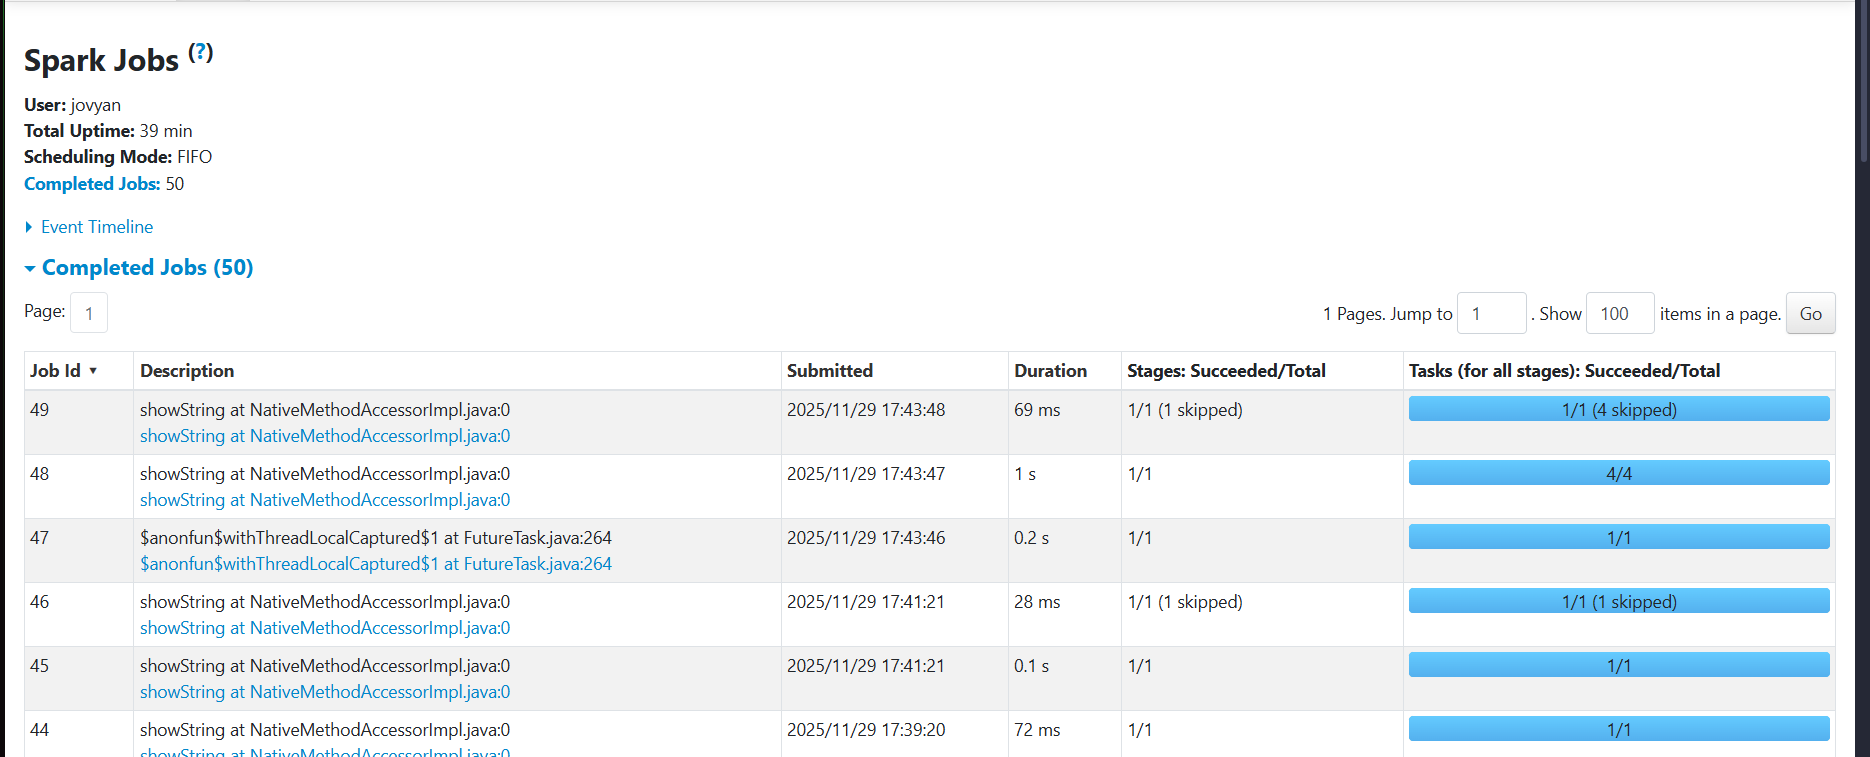